# 🛍️ Product Image Classification
### CNN-Based E-Commerce Product Categorisation using Transfer Learning & Explainability
---
**Models:** Custom CNN · MobileNetV2 · ResNet50  
**Explainability:** Grad-CAM · SHAP  
**Dataset:** [Fashion Products Images – Kaggle](https://www.kaggle.com/datasets/bhavikjikadara/e-commerce-products-images)


---
## 📦 Step 1: Install & Import Libraries

In [1]:
import os, random, warnings, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shap

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")


2026-06-27 18:52:12.524222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782586332.722021      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782586332.787143      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782586333.318338      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586333.318377      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586333.318380      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📂 Step 2: Dataset Loading & Exploration

In [2]:
BASE_DIR   = Path('/kaggle/input/datasets/bhavikjikadara/e-commerce-products-images')
IMAGE_DIR  = BASE_DIR / 'e-commerce' / 'images'
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR  exists : {BASE_DIR.exists()}")
print(f"IMAGE_DIR exists : {IMAGE_DIR.exists()}")
print(f"OUTPUT_DIR       : {OUTPUT_DIR}")


BASE_DIR  exists : True
IMAGE_DIR exists : True
OUTPUT_DIR       : /kaggle/working/outputs


In [3]:
df = pd.read_csv(BASE_DIR / 'styles.csv', on_bad_lines='skip')
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()


Shape   : (44441, 10)
Columns : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44441 non-null  int64  
 1   gender              44441 non-null  object 
 2   masterCategory      44441 non-null  object 
 3   subCategory         44441 non-null  object 
 4   articleType         44441 non-null  object 
 5   baseColour          44426 non-null  object 
 6   season              44420 non-null  object 
 7   year                44440 non-null  float64
 8   usage               44124 non-null  object 
 9   productDisplayName  44434 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB
None

Missing values:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage      

In [5]:
LABEL_COL = 'masterCategory'

df['image_path'] = df['id'].astype(str).apply(lambda x: str(IMAGE_DIR / f"{x}.jpg"))
df['exists']     = df['image_path'].apply(os.path.exists)
df               = df[df['exists']].drop(columns='exists').reset_index(drop=True)
print(f"Images found on disk: {len(df):,}")


Images found on disk: 44,441


Classes : 7
masterCategory
Apparel           21395
Accessories       11289
Footwear           9222
Personal Care      2404
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


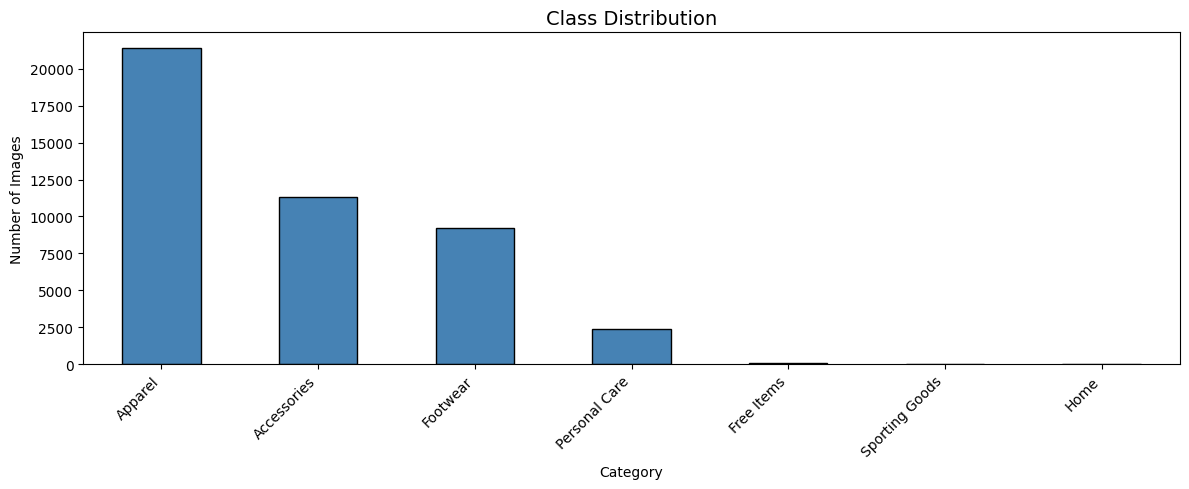

In [6]:
class_counts = df[LABEL_COL].value_counts()
print(f"Classes : {len(class_counts)}")
print(class_counts)

plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Category'); plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.pdf', dpi=150)
plt.show()


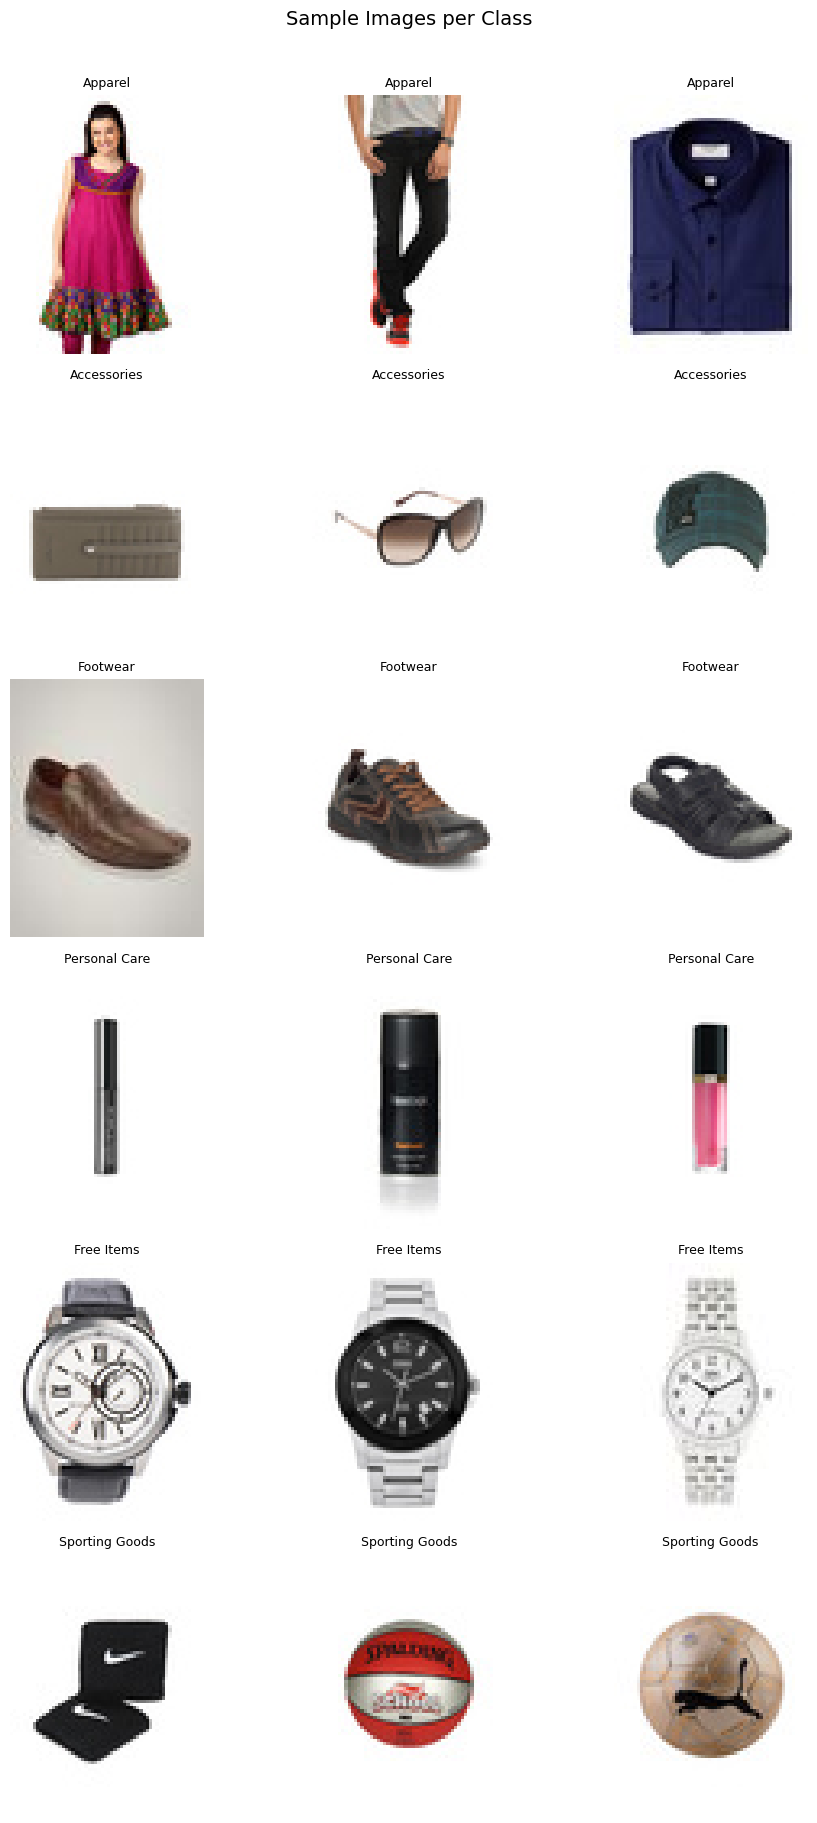

In [7]:
classes = class_counts.index.tolist()
fig, axes = plt.subplots(min(len(classes), 6), 3, figsize=(10, min(len(classes), 6) * 3))
axes = axes.flatten()
ax_idx = 0
for cls in classes[:6]:
    for _, row in df[df[LABEL_COL] == cls].sample(3, random_state=SEED).iterrows():
        axes[ax_idx].imshow(Image.open(row['image_path']).convert('RGB'))
        axes[ax_idx].set_title(cls, fontsize=9); axes[ax_idx].axis('off')
        ax_idx += 1
plt.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## ✂️ Step 3: Preprocessing & Train / Val / Test Split

In [8]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS_CNN = 30
EPOCHS_TL  = 20

MIN_SAMPLES   = 50
class_counts  = df[LABEL_COL].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
df_filtered   = df[df[LABEL_COL].isin(valid_classes)].copy().reset_index(drop=True)

NUM_CLASSES = len(valid_classes)
CLASS_NAMES = sorted(valid_classes)
INPUT_SHAPE = IMG_SIZE + (3,)

print(f"Classes kept : {NUM_CLASSES}  →  {CLASS_NAMES}")
print(f"Images kept  : {len(df_filtered):,}")


Classes kept : 5  →  ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Personal Care']
Images kept  : 44,415


In [9]:
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df_filtered['label'] = df_filtered[LABEL_COL].map(label2idx)

train_df, temp_df = train_test_split(
    df_filtered, test_size=0.30, stratify=df_filtered['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")

# Reset index — required for positional lookup in Grad-CAM misclassified section
test_df_reset = test_df.reset_index(drop=True)


Train : 31,090  |  Val : 6,662  |  Test : 6,663


In [10]:
# ── Custom CNN generators (rescale inside datagen) ────────────────────────────
train_datagen   = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, shear_range=0.10, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8,1.2], fill_mode='nearest')
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=dataframe, x_col='image_path', y_col=LABEL_COL,
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASS_NAMES,
        shuffle=shuffle, seed=SEED)

train_gen = make_gen(train_datagen,    train_df, shuffle=True)
val_gen   = make_gen(val_test_datagen, val_df,   shuffle=False)
test_gen  = make_gen(val_test_datagen, test_df,  shuffle=False)

# ── Transfer Learning generators (NO rescale; preprocess is inside model) ─────
tl_aug_datagen  = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.10, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
tl_val_datagen  = ImageDataGenerator()   # backbone preprocess is inside the model

tl_train_gen = make_gen(tl_aug_datagen, train_df, shuffle=True)
tl_val_gen   = make_gen(tl_val_datagen, val_df,   shuffle=False)
tl_test_gen  = make_gen(tl_val_datagen, test_df,  shuffle=False)

print("Class indices:", train_gen.class_indices)


Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.
Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.
Class indices: {'Accessories': 0, 'Apparel': 1, 'Footwear': 2, 'Free Items': 3, 'Personal Care': 4}


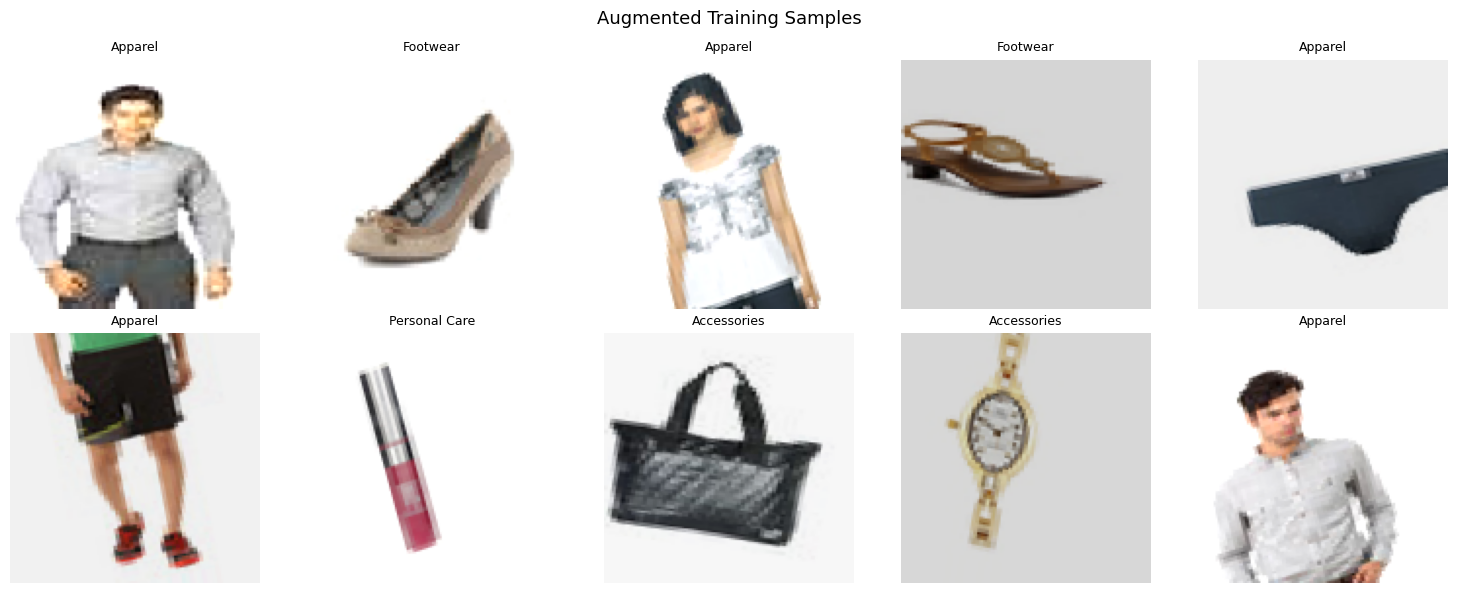

In [11]:
batch_imgs, batch_lbls = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_imgs[i]); ax.set_title(CLASS_NAMES[np.argmax(batch_lbls[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmented_samples.pdf', dpi=150)
plt.show()


---
## 🧠 Step 4: Custom CNN Model

In [12]:
def build_custom_cnn(input_shape, num_classes):
    """4-block CNN with BatchNorm, GlobalAveragePooling, and L2 regularisation."""
    m = models.Sequential(name='Custom_CNN')

    m.add(keras.Input(shape=input_shape))
    for filters, drop in [(32,0.25),(64,0.25),(128,0.30),(256,0.30)]:
        m.add(layers.Conv2D(filters,(3,3),padding='same'))
        m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
        if filters < 256:
            m.add(layers.Conv2D(filters,(3,3),padding='same'))
            m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
        m.add(layers.MaxPooling2D(2,2)); m.add(layers.Dropout(drop))
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    m.add(layers.Dropout(0.50))
    m.add(layers.Dense(num_classes, activation='softmax'))
    return m

cnn_model = build_custom_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()


I0000 00:00:1782586512.804993      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 652,069 (2.49 MB)

 Trainable params: 650,661 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
cnn_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cnn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_cnn.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1)
]


In [14]:
start_time  = time.time()
cnn_history = cnn_model.fit(
    train_gen, epochs=EPOCHS_CNN,
    validation_data=val_gen, callbacks=cnn_callbacks, verbose=1)
cnn_time    = time.time() - start_time
print(f"Custom CNN training time: {cnn_time:.1f}s")

Epoch 1/30


I0000 00:00:1782586520.926843      70 service.cc:152] XLA service 0x7c99a001f780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782586520.926900      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782586521.972916      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/972 ━━━━━━━━━━━━━━━━━━━━ 4:09:49 15s/step - accuracy: 0.3438 - loss: 1.9267

I0000 00:00:1782586531.035671      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.7108 - loss: 0.7456
Epoch 1: val_accuracy improved from None to 0.65356, saving model to /kaggle/working/outputs/best_cnn.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_cnn.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 316s 310ms/step - accuracy: 0.7795 - loss: 0.5995 - val_accuracy: 0.6536 - val_loss: 2.6970 - learning_rate: 0.0010
Epoch 2/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8620 - loss: 0.4188
Epoch 2: val_accuracy did not improve from 0.65356
972/972 ━━━━━━━━━━━━━━━━━━━━ 176s 181ms/step - accuracy: 0.8727 - loss: 0.3939 - val_accuracy: 0.5269 - val_loss: 1.2032 - learning_rate: 0.0010
Epoch 3/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8985 - loss: 0.3329
Epoch 3: val_accuracy improved from 0.65356 to 0.69379, saving model to /kaggle/working/outputs/best_cnn.keras

Epoch 3: finished saving model to /kaggle/working/outputs/best_cnn.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 177s 182ms

---
## 📈 Step 5: Training Curves

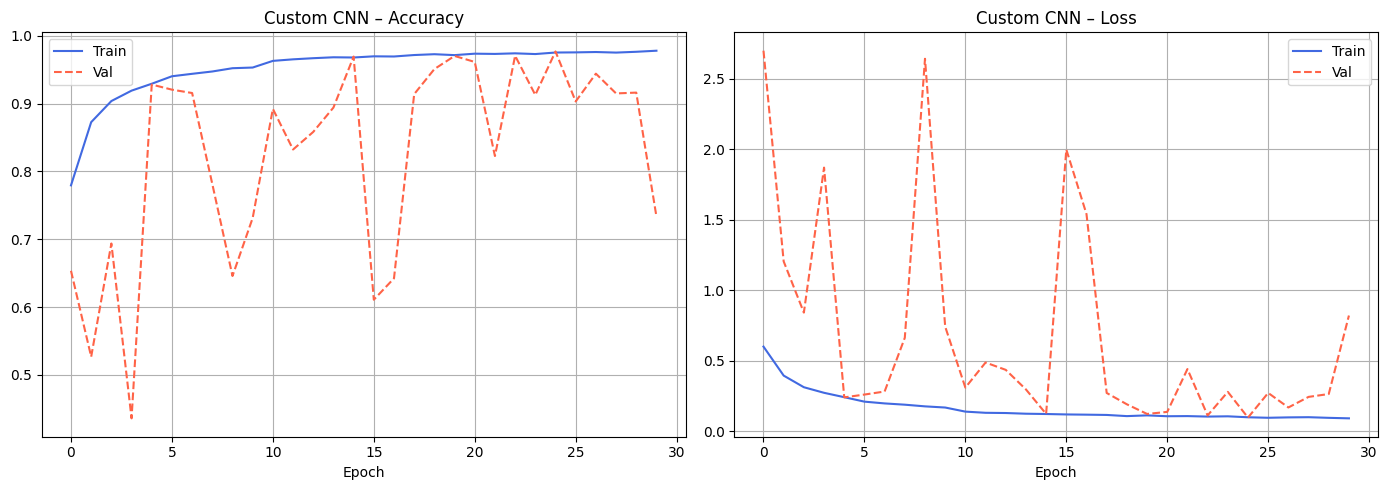

In [15]:
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train', color='royalblue')
    ax1.plot(history.history['val_accuracy'], label='Val',   color='tomato', ls='--')
    ax1.set_title(f'{title} – Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(0.3)
    ax2.plot(history.history['loss'],     label='Train', color='royalblue')
    ax2.plot(history.history['val_loss'], label='Val',   color='tomato', ls='--')
    ax2.set_title(f'{title} – Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

plot_history(cnn_history, 'Custom CNN', OUTPUT_DIR / 'cnn_curves.pdf')


---
## 📊 Step 6: Evaluate Custom CNN

209/209 ━━━━━━━━━━━━━━━━━━━━ 51s 239ms/step

  Custom_CNN – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9616    0.9604    0.9610      1694
      Apparel     0.9906    0.9829    0.9867      3210
     Footwear     0.9892    0.9928    0.9910      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.8841    0.9750    0.9273       360

     accuracy                         0.9766      6663
    macro avg     0.7651    0.7822    0.7732      6663
 weighted avg     0.9749    0.9766    0.9756      6663



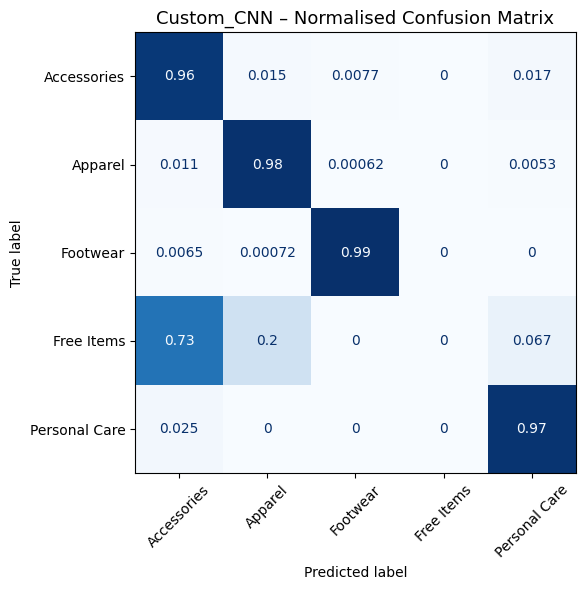

Accuracy=0.9766  Precision=0.7651  Recall=0.7822  F1=0.7732


In [16]:
def evaluate_model(model, test_gen, class_names, model_name, output_dir):
    """Predict on test set, print classification report, plot confusion matrix."""
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*55}\n  {model_name} – Classification Report\n{'='*55}")
    print(report)
    pd.DataFrame(
        classification_report(y_true, y_pred, target_names=class_names,
                              digits=4, output_dict=True)
    ).T.round(4).to_csv(output_dir / f'{model_name}_report.csv')

    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names)-2)))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{model_name} – Normalised Confusion Matrix', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_confusion_matrix.pdf', dpi=150, bbox_inches='tight')
    plt.show()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    return dict(accuracy=acc, precision=prec, recall=rec, macro_f1=f1,
                y_prob=y_prob, y_pred=y_pred, y_true=y_true)

cnn_results = evaluate_model(cnn_model, test_gen, CLASS_NAMES, 'Custom_CNN', OUTPUT_DIR)


---
## 🔁 Step 7: Transfer Learning – MobileNetV2

In [17]:
def build_transfer_model(base_fn, preprocess_fn, input_shape, num_classes, name='TL'):
    """Transfer learning model: frozen ImageNet base + custom dense head.
    NOTE: preprocess_fn is applied inside the model, so generators must NOT rescale."""    
    base = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = preprocess_fn(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out, name=name)

mobilenet_model = build_transfer_model(
    MobileNetV2, preprocess_input, INPUT_SHAPE, NUM_CLASSES, name='MobileNetV2')
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9273 - loss: 0.2868
Epoch 1: val_accuracy improved from None to 0.96953, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 201s 195ms/step - accuracy: 0.9532 - loss: 0.2015 - val_accuracy: 0.9695 - val_loss: 0.1454 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9676 - loss: 0.1565
Epoch 2: val_accuracy improved from 0.96953 to 0.97523, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 174s 179ms/step - accuracy: 0.9696 - loss: 0.1522 - val_accuracy: 0.9752 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9733 - loss: 0.1390
Epoch 3: val_accuracy improved from 0.97523 to 0.98034,

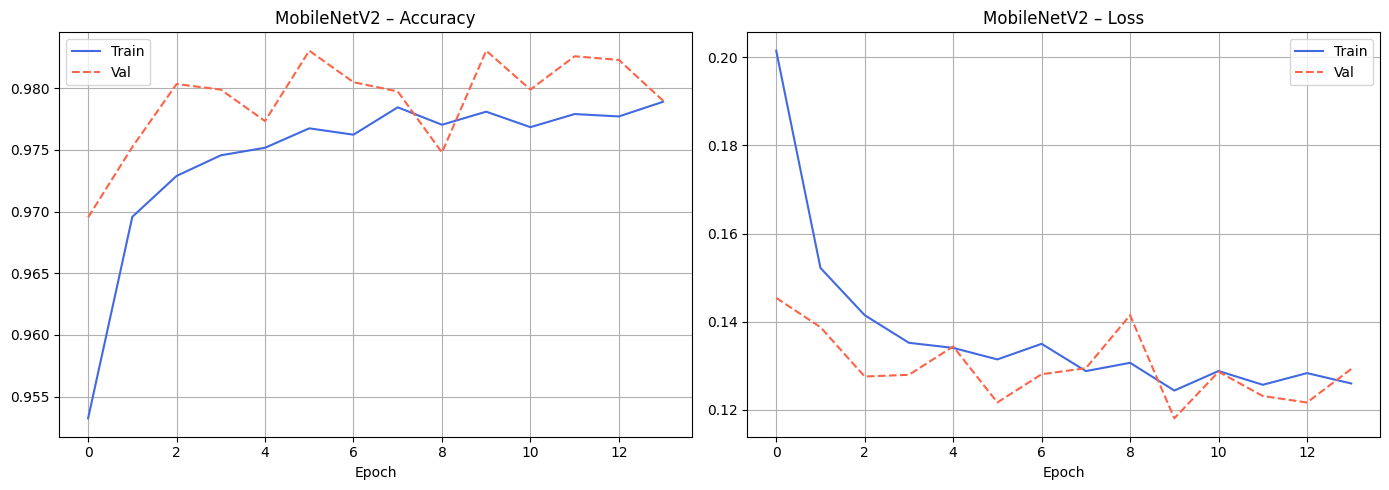

In [18]:
# ── Phase 1: Feature Extraction (base frozen) ─────────────────────────────────
mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

mn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_mobilenet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

start_time        = time.time()
mobilenet_history = mobilenet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen, callbacks=mn_callbacks, verbose=1)
mobilenet_time    = time.time() - start_time
print(f"MobileNetV2 Phase 1 time: {mobilenet_time:.1f}s")
plot_history(mobilenet_history, 'MobileNetV2', OUTPUT_DIR/'mobilenet_curves.pdf')


Epoch 1/10


2026-06-27 21:10:42.138132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 21:10:42.335195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


569/972 ━━━━━━━━━━━━━━━━━━━━ 1:08 169ms/step - accuracy: 0.9324 - loss: 0.2666

2026-06-27 21:12:25.705935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 21:12:25.906603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9402 - loss: 0.2431
Epoch 1: val_accuracy improved from None to 0.98034, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 206s 196ms/step - accuracy: 0.9546 - loss: 0.1989 - val_accuracy: 0.9803 - val_loss: 0.1331 - learning_rate: 1.0000e-05
Epoch 2/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9695 - loss: 0.1520
Epoch 2: val_accuracy improved from 0.98034 to 0.98094, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 177s 182ms/step - accuracy: 0.9708 - loss: 0.1482 - val_accuracy: 0.9809 - val_loss: 0.1277 - learning_rate: 1.0000e-05
Epoch 3/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9744 - loss: 0.1353
Epoch 3: val_accuracy improved from 0.98094 to 0.98139, sa

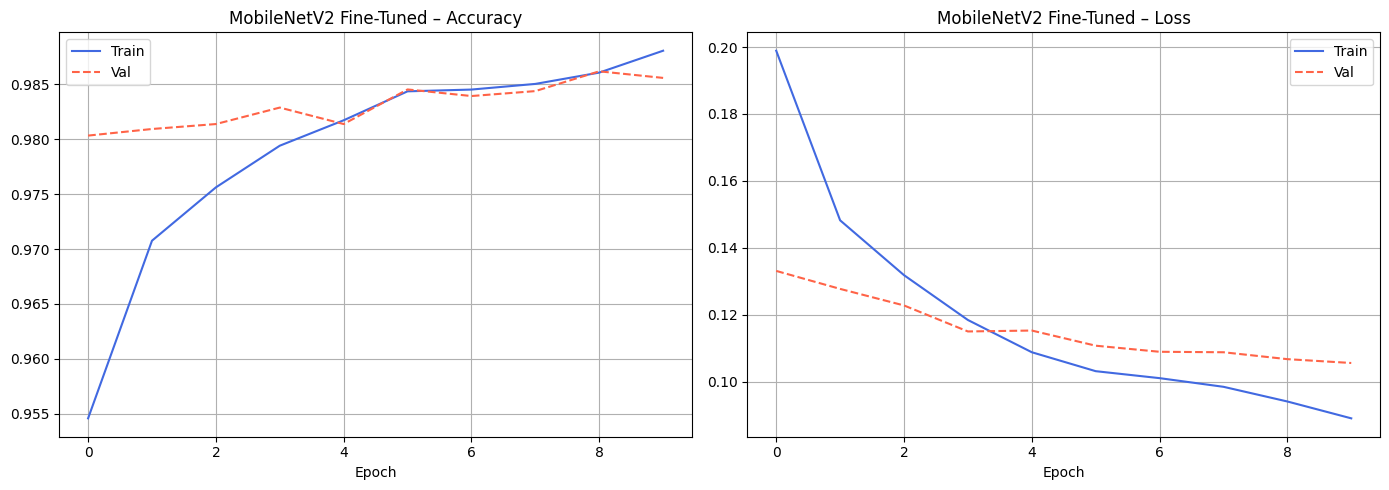

In [19]:
# ── Phase 2: Fine-Tuning (unfreeze top 30 layers of base) ────────────────────
# Locate the MobileNetV2 base layer dynamically (name varies with input size)
mn_base = next(l for l in mobilenet_model.layers if l.name.startswith('mobilenetv2'))
mn_base.trainable = True
for layer in mn_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy'])

mn_ft_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_mobilenet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

finetune_history = mobilenet_model.fit(
    tl_train_gen, epochs=10,
    validation_data=tl_val_gen, callbacks=mn_ft_callbacks, verbose=1)
plot_history(finetune_history, 'MobileNetV2 Fine-Tuned',
             OUTPUT_DIR/'mobilenet_finetune_curves.pdf')


209/209 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step

  MobileNetV2 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9709    0.9858    0.9783      1694
      Apparel     0.9938    0.9950    0.9944      3210
     Footwear     0.9985    0.9906    0.9946      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9747    0.9639    0.9693       360

     accuracy                         0.9878      6663
    macro avg     0.7876    0.7871    0.7873      6663
 weighted avg     0.9857    0.9878    0.9867      6663



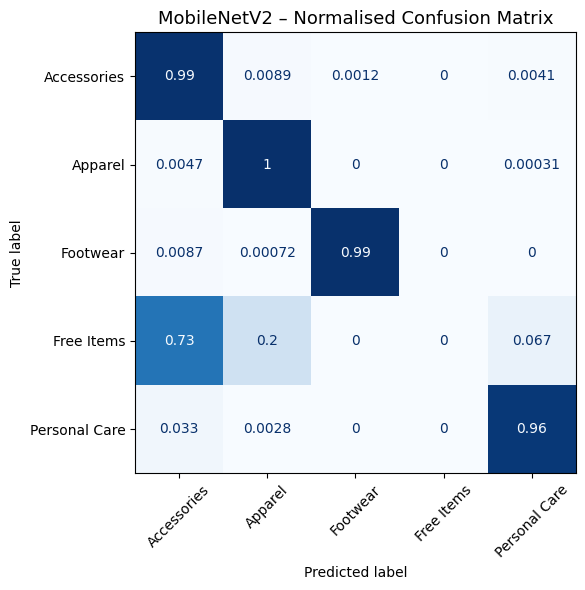

Accuracy=0.9878  Precision=0.7876  Recall=0.7871  F1=0.7873


In [20]:
mobilenet_results = evaluate_model(
    mobilenet_model, tl_test_gen, CLASS_NAMES, 'MobileNetV2', OUTPUT_DIR)


---
## 🔁 Step 8: Transfer Learning – ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │      1,285 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9217 - loss: 0.3415
Epoch 1: val_accuracy improved from None to 0.96998, saving model to /kaggle/working/outputs/best_resnet50.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_resnet50.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 198s 193ms/step - accuracy: 0.9475 - loss: 0.2334 - val_accuracy: 0.9700 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9670 - loss: 0.1655
Epoch 2: val_accuracy improved from 0.96998 to 0.97838, saving model to /kaggle/working/outputs/best_resnet50.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_resnet50.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 178s 183ms/step - accuracy: 0.9647 - loss: 0.1719 - val_accuracy: 0.9784 - val_loss: 0.1309 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9653 - loss: 0.1662
Epoch 3: val_accuracy did not improve from 0.97838
972/972 

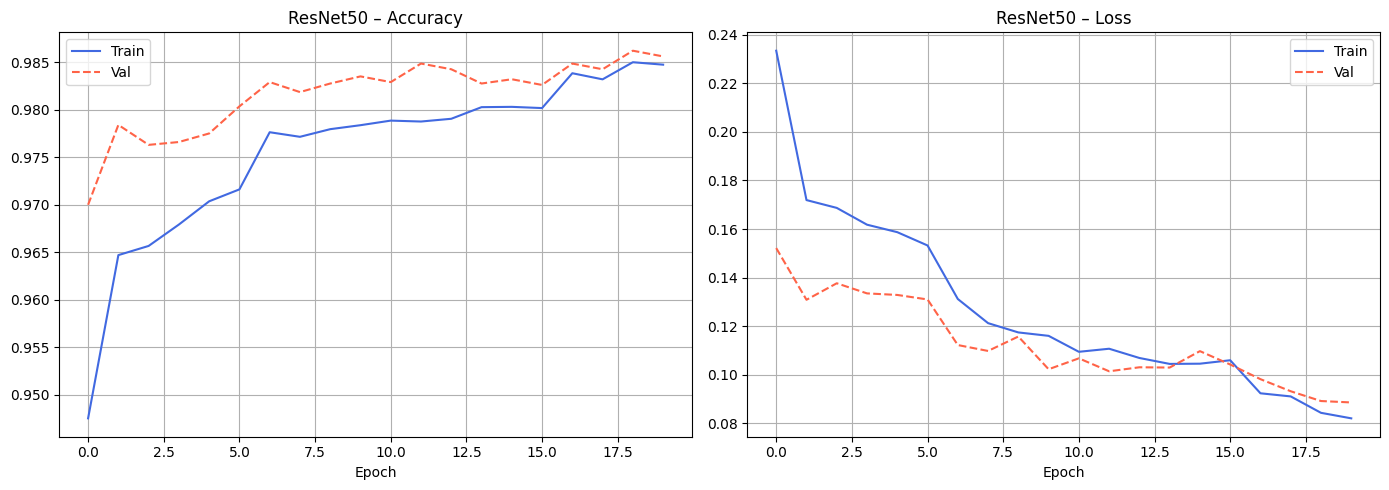

209/209 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step

  ResNet50 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9816    0.9770    0.9793      1694
      Apparel     0.9913    0.9981    0.9947      3210
     Footwear     0.9957    0.9957    0.9957      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9695    0.9722    0.9709       360

     accuracy                         0.9886      6663
    macro avg     0.7876    0.7886    0.7881      6663
 weighted avg     0.9864    0.9886    0.9875      6663



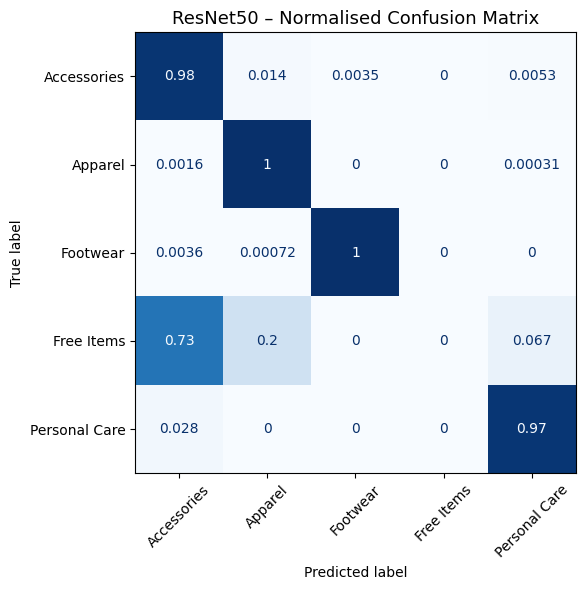

Accuracy=0.9886  Precision=0.7876  Recall=0.7886  F1=0.7881


In [21]:
resnet_model = build_transfer_model(
    ResNet50, resnet_preprocess, INPUT_SHAPE, NUM_CLASSES, name='ResNet50')
resnet_model.summary()

resnet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

# Separate callbacks so ResNet50 checkpoint does not overwrite MobileNetV2
rn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_resnet50.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

start_time     = time.time()
resnet_history = resnet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen, callbacks=rn_callbacks, verbose=1)
resnet_time    = time.time() - start_time
print(f"ResNet50 training time: {resnet_time:.1f}s")
plot_history(resnet_history, 'ResNet50', OUTPUT_DIR/'resnet_curves.pdf')

resnet_results = evaluate_model(
    resnet_model, tl_test_gen, CLASS_NAMES, 'ResNet50', OUTPUT_DIR)


---
## 📊 Step 9: Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model':         ['Custom CNN', 'MobileNetV2', 'ResNet50'],
    'Accuracy':      [cnn_results['accuracy'],      mobilenet_results['accuracy'],      resnet_results['accuracy']],
    'Precision':     [cnn_results['precision'],     mobilenet_results['precision'],     resnet_results['precision']],
    'Recall':        [cnn_results['recall'],        mobilenet_results['recall'],        resnet_results['recall']],
    'Macro F1':      [cnn_results['macro_f1'],      mobilenet_results['macro_f1'],      resnet_results['macro_f1']],
    'Training Time': [f"{cnn_time:.1f}s",           f"{mobilenet_time:.1f}s",           f"{resnet_time:.1f}s"],
    'Parameters':    [cnn_model.count_params(),     mobilenet_model.count_params(),     resnet_model.count_params()],
}).round({'Accuracy':4,'Precision':4,'Recall':4,'Macro F1':4})

comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
comparison


,Model,Accuracy,Precision,Recall,Macro F1,Training Time,Parameters
0,Custom CNN,0.9766,0.7651,0.7822,0.7732,5538.4s,652069
1,MobileNetV2,0.9878,0.7876,0.7871,0.7873,2499.6s,2587205
2,ResNet50,0.9886,0.7876,0.7886,0.7881,3603.1s,24113541


---
## 🌡️ Step 10: Grad-CAM Visualisation

Grad-CAM highlights the image regions each model focused on when making predictions. Applied to correctly classified test images for all three models.

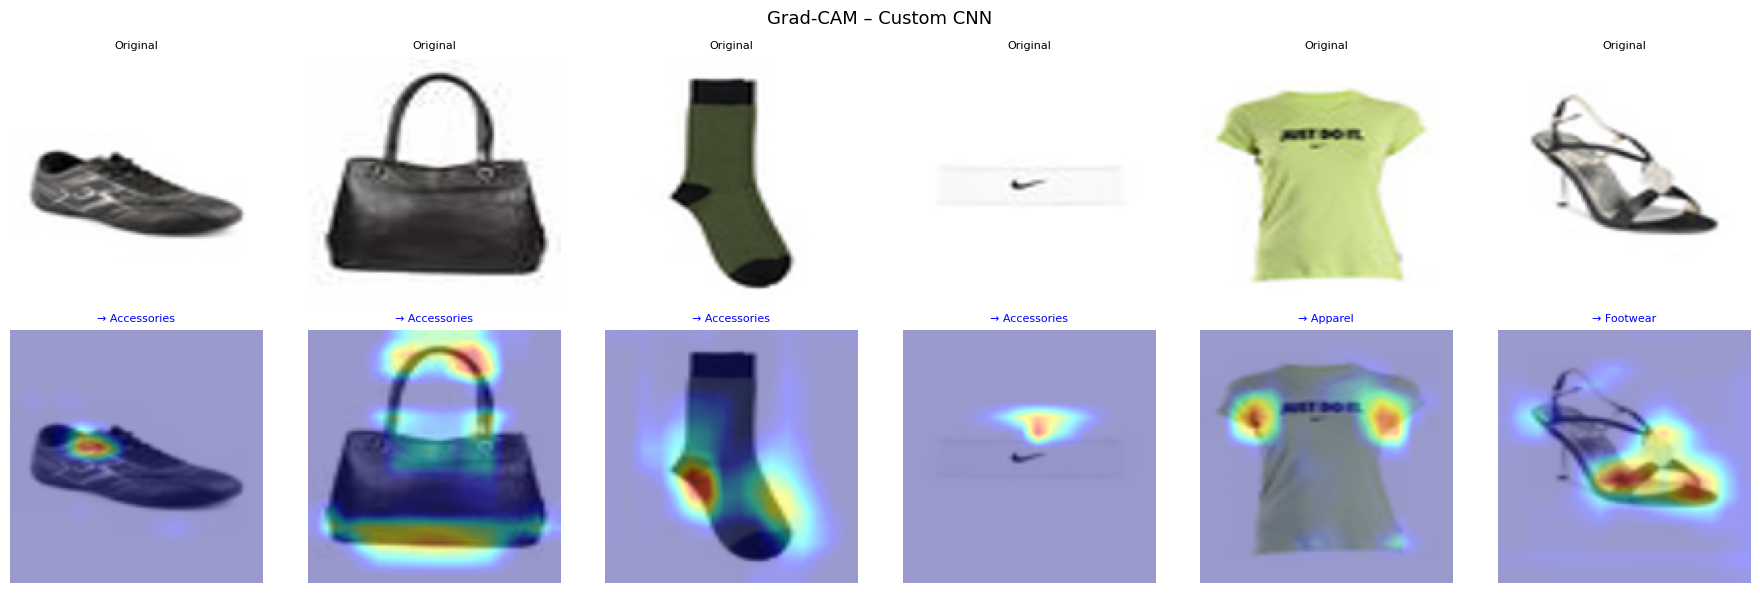

In [23]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    # Rebuild model graph
    inputs = tf.keras.Input(shape=model.input_shape[1:])

    x = inputs
    last_conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, x]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            tf.cast(img_array, tf.float32),
            training=False
        )

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image. Returns RGB numpy array."""
    img          = cv2.imread(str(img_path))
    img          = cv2.resize(img, IMG_SIZE)
    h_resized    = cv2.resize(np.float32(heatmap), IMG_SIZE)
    h_uint8      = np.uint8(255 * h_resized)
    h_color      = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1-alpha, h_color, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)


# ── Grad-CAM: Custom CNN ──────────────────────────────────────────────────────
# Find last Conv2D layer in the Sequential model
last_conv = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)][-1]

sample_paths = test_df_reset.sample(6, random_state=SEED)['image_path'].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, path in enumerate(sample_paths):
    img_pil = Image.open(path).convert('RGB').resize(IMG_SIZE)
    # CNN expects 0-1 range (rescale=1/255 is in datagen)
    img_arr = np.expand_dims(np.array(img_pil) / 255.0, 0).astype('float32')
    heatmap, pred_idx = get_gradcam_heatmap(cnn_model, img_arr, last_conv)
    axes[0][col].imshow(img_pil);                axes[0][col].set_title('Original', fontsize=8);                axes[0][col].axis('off')
    axes[1][col].imshow(overlay_gradcam(path, heatmap))
    axes[1][col].set_title(f'→ {CLASS_NAMES[pred_idx]}', fontsize=8, color='blue')
    axes[1][col].axis('off')
plt.suptitle('Grad-CAM – Custom CNN', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## 🌡️ Grad-CAM – MobileNetV2

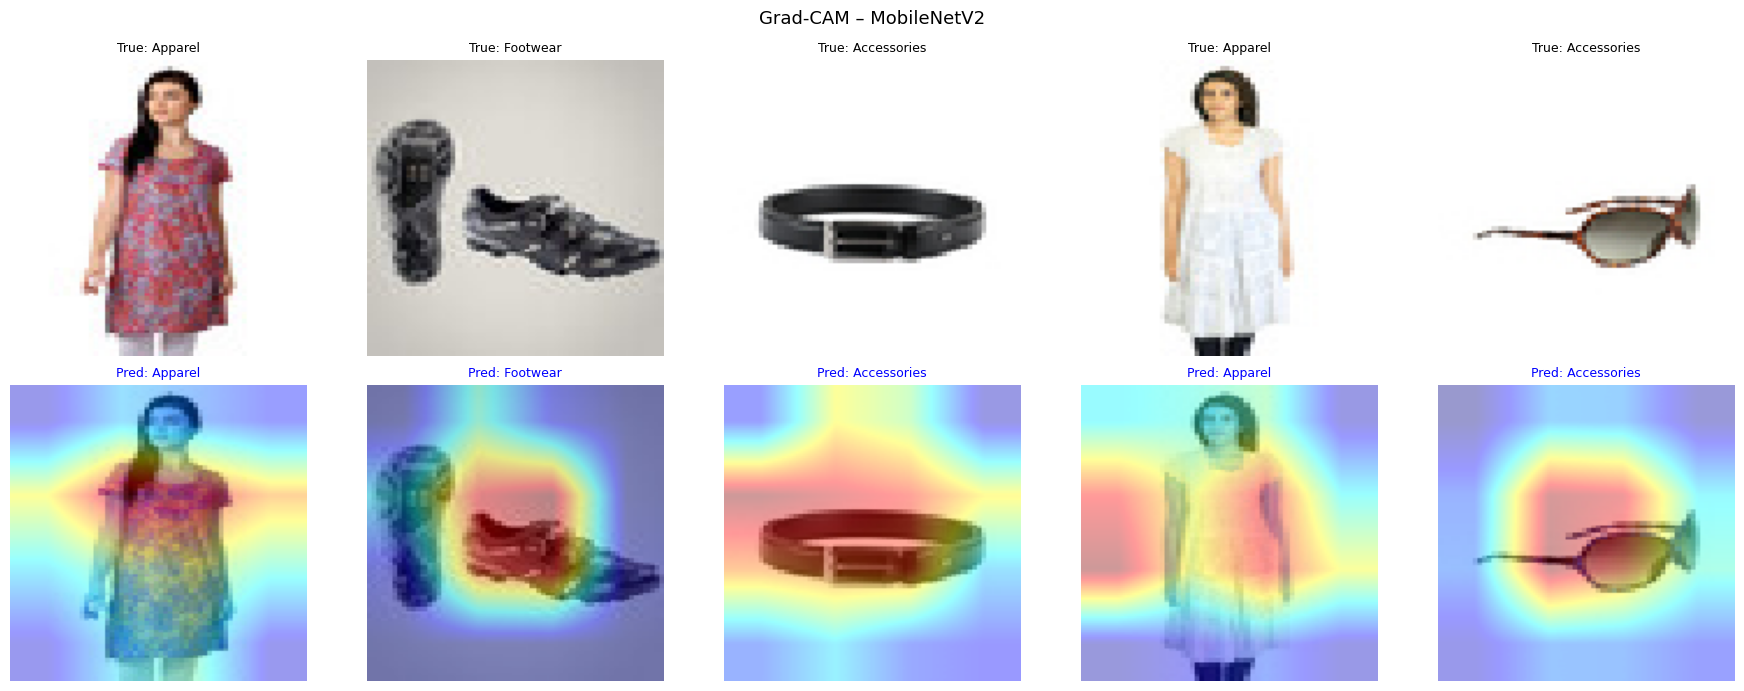

In [24]:
def get_gradcam_heatmap_mobilenet(model, img_array):

    # MobileNetV2 backbone
    base_model = model.get_layer("mobilenetv2_1.00_128")

    # Classification head
    classifier = tf.keras.Sequential(model.layers[2:])

    with tf.GradientTape() as tape:

        processed = preprocess_input(
            tf.cast(img_array, tf.float32)
        )
        
        conv_outputs = base_model(
            processed,
            training=False
        )

        tape.watch(conv_outputs)

        # Forward through classifier head
        predictions = classifier(
            conv_outputs,
            training=False
        )

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(
        conv_outputs[0] * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy(), int(pred_index)

# Use tl_test_gen — images in 0-255 range, preprocess is inside the model
images_mn, labels_mn = next(tl_test_gen)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(5):
    img_arr = np.expand_dims(images_mn[i], 0).astype('float32')  # 0-255, handled inside model
    heatmap, pred_idx = get_gradcam_heatmap_mobilenet(
    mobilenet_model,
    img_arr
    )

    disp = images_mn[i].copy()
    if disp.max() > 1.0:
        disp = disp.astype(np.uint8)  # keep 0-255 for overlay

    h_r   = cv2.resize(np.uint8(255 * heatmap), (disp.shape[1], disp.shape[0]))
    over  = cv2.addWeighted(disp, 0.6, cv2.applyColorMap(h_r, cv2.COLORMAP_JET), 0.4, 0)

    axes[0][i].imshow(disp.astype(np.uint8)); axes[0][i].axis('off')
    axes[0][i].set_title(f"True: {CLASS_NAMES[np.argmax(labels_mn[i])]}", fontsize=9)
    axes[1][i].imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB)); axes[1][i].axis('off')
    axes[1][i].set_title(f"Pred: {CLASS_NAMES[pred_idx]}", fontsize=9, color='blue')

plt.suptitle('Grad-CAM – MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mobilenet_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()

---
## 🌡️ Grad-CAM – ResNet50

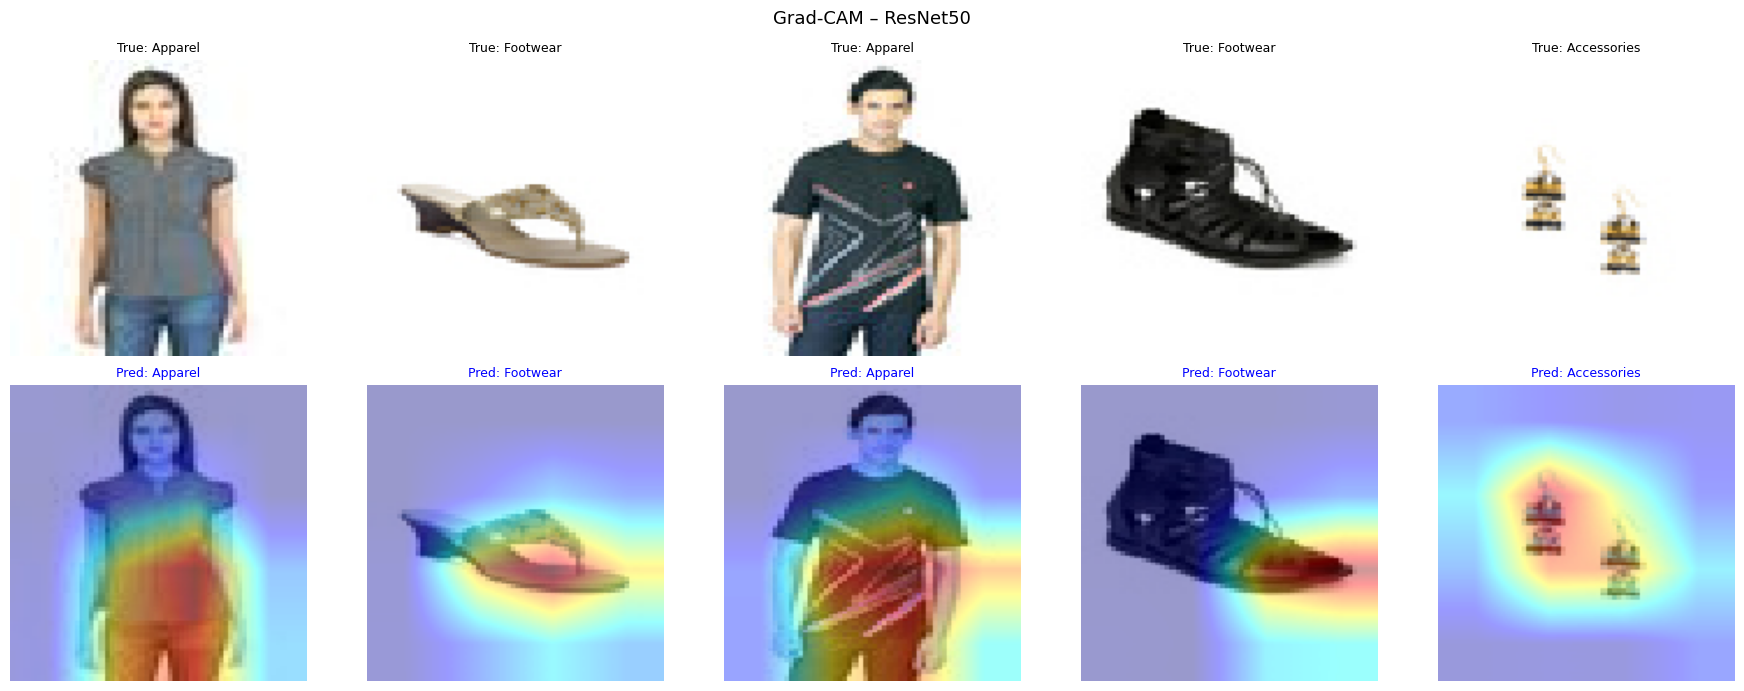

In [25]:
def get_gradcam_heatmap_resnet(model, img_array):

    base_model = model.layers[1]   # ResNet50 backbone

    # Apply ResNet preprocessing
    processed = tf.keras.applications.resnet50.preprocess_input(
        tf.cast(img_array, tf.float32)
    )

    # Forward through backbone
    conv_outputs = base_model(processed, training=False)

    # Classification head
    x = conv_outputs
    for layer in model.layers[2:]:
        x = layer(x, training=False)

    predictions = x

    pred_index = tf.argmax(predictions[0])

    with tf.GradientTape() as tape:

        conv_outputs = base_model(processed, training=False)
        tape.watch(conv_outputs)

        x = conv_outputs
        for layer in model.layers[2:]:
            x = layer(x, training=False)

        predictions = x
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = tf.reduce_sum(
        conv_outputs[0] * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index)

images_rn, labels_rn = next(tl_test_gen)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(5):
    img_arr = np.expand_dims(images_rn[i], 0).astype('float32')
    heatmap, pred_idx = get_gradcam_heatmap_resnet(
    resnet_model,
    img_arr
    )

    disp = images_rn[i].copy()
    if disp.max() > 1.0:
        disp = disp.astype(np.uint8)

    h_r  = cv2.resize(np.uint8(255 * heatmap), (disp.shape[1], disp.shape[0]))
    over = cv2.addWeighted(disp, 0.6, cv2.applyColorMap(h_r, cv2.COLORMAP_JET), 0.4, 0)

    axes[0][i].imshow(disp.astype(np.uint8)); axes[0][i].axis('off')
    axes[0][i].set_title(f"True: {CLASS_NAMES[np.argmax(labels_rn[i])]}", fontsize=9)
    axes[1][i].imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB)); axes[1][i].axis('off')
    axes[1][i].set_title(f"Pred: {CLASS_NAMES[pred_idx]}", fontsize=9, color='blue')

plt.suptitle('Grad-CAM – ResNet50', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resnet_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## 🔴 Step 11: Grad-CAM on Misclassified Images

Grad-CAM is applied specifically to misclassified test images to diagnose *why* each model made the wrong prediction.

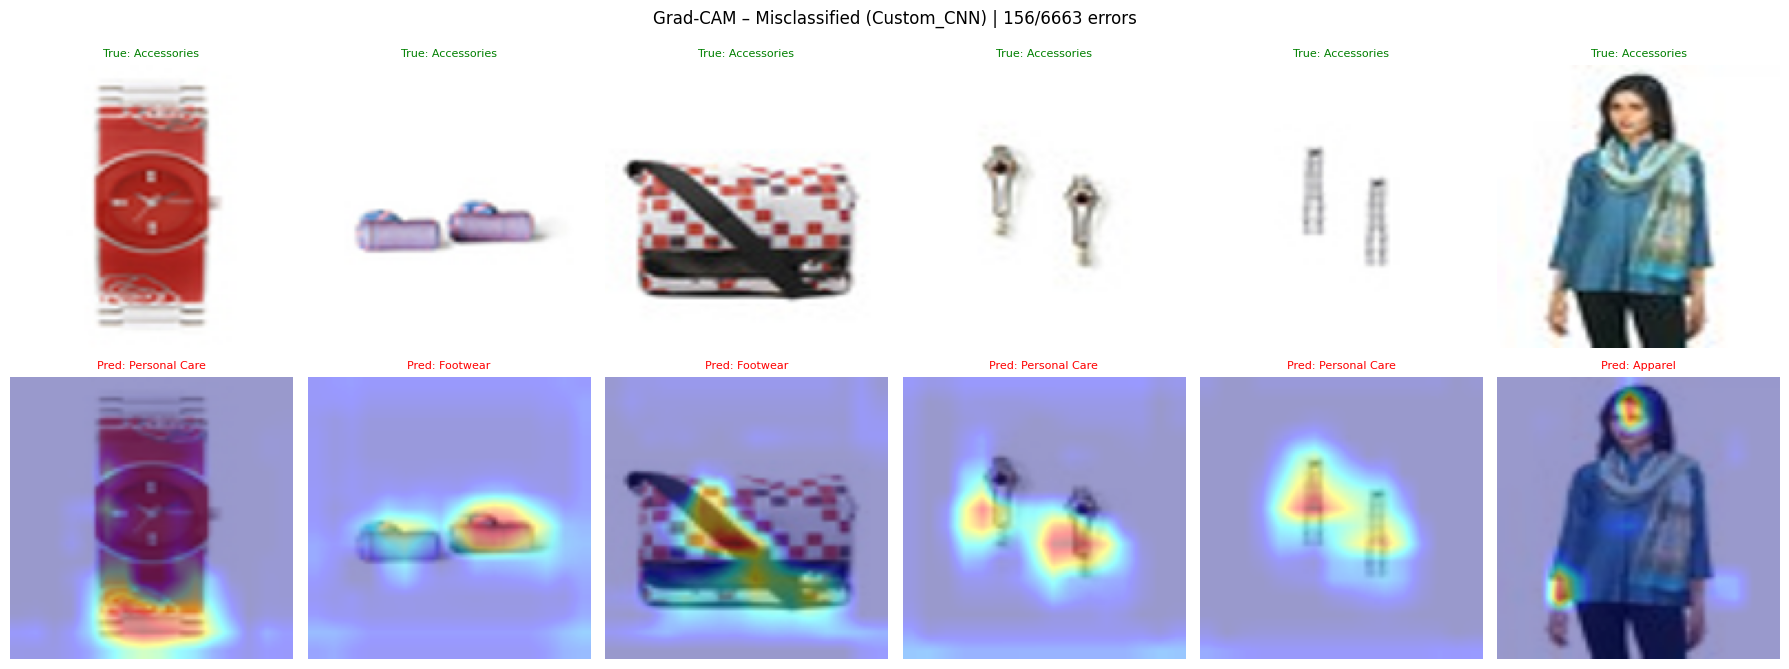

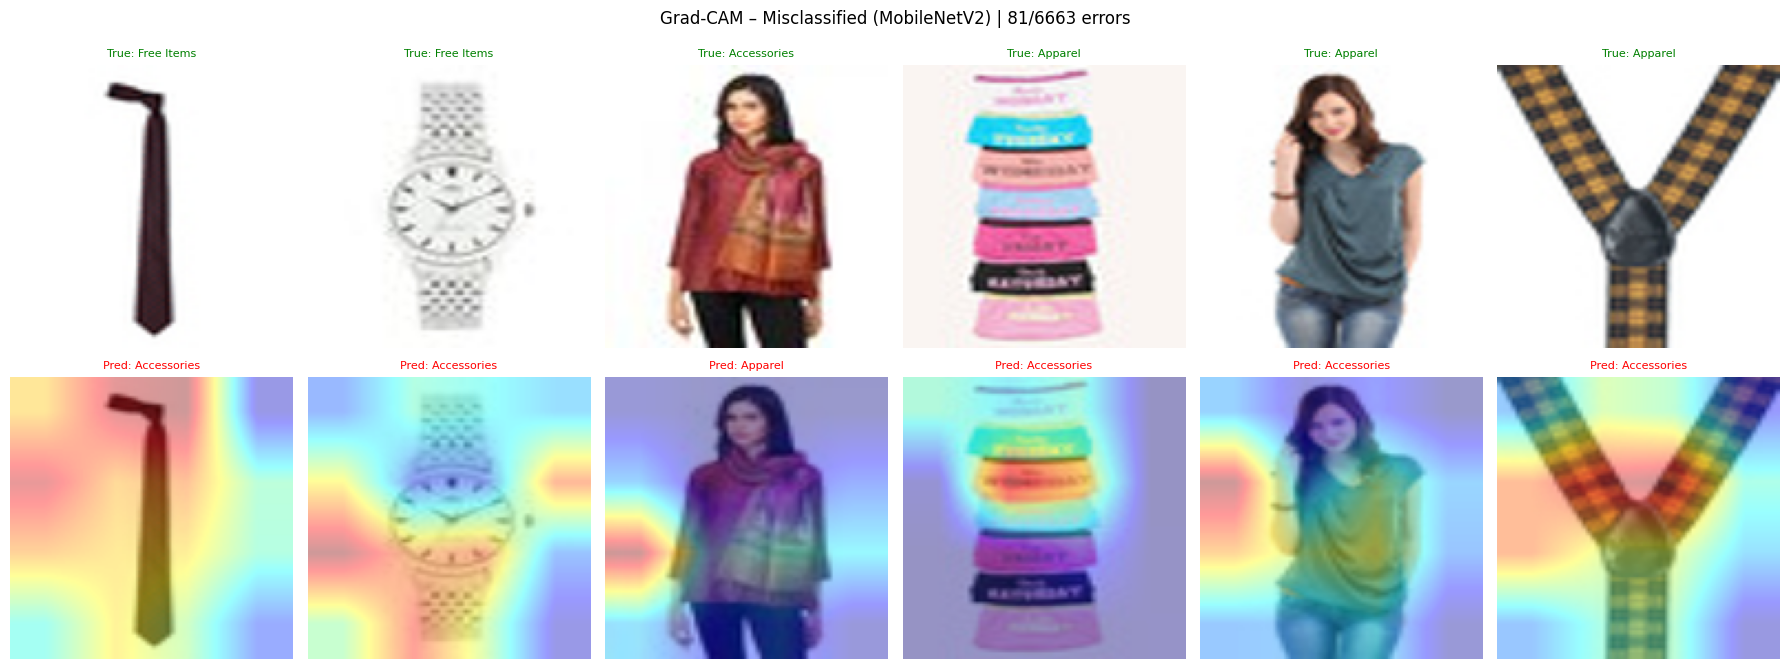

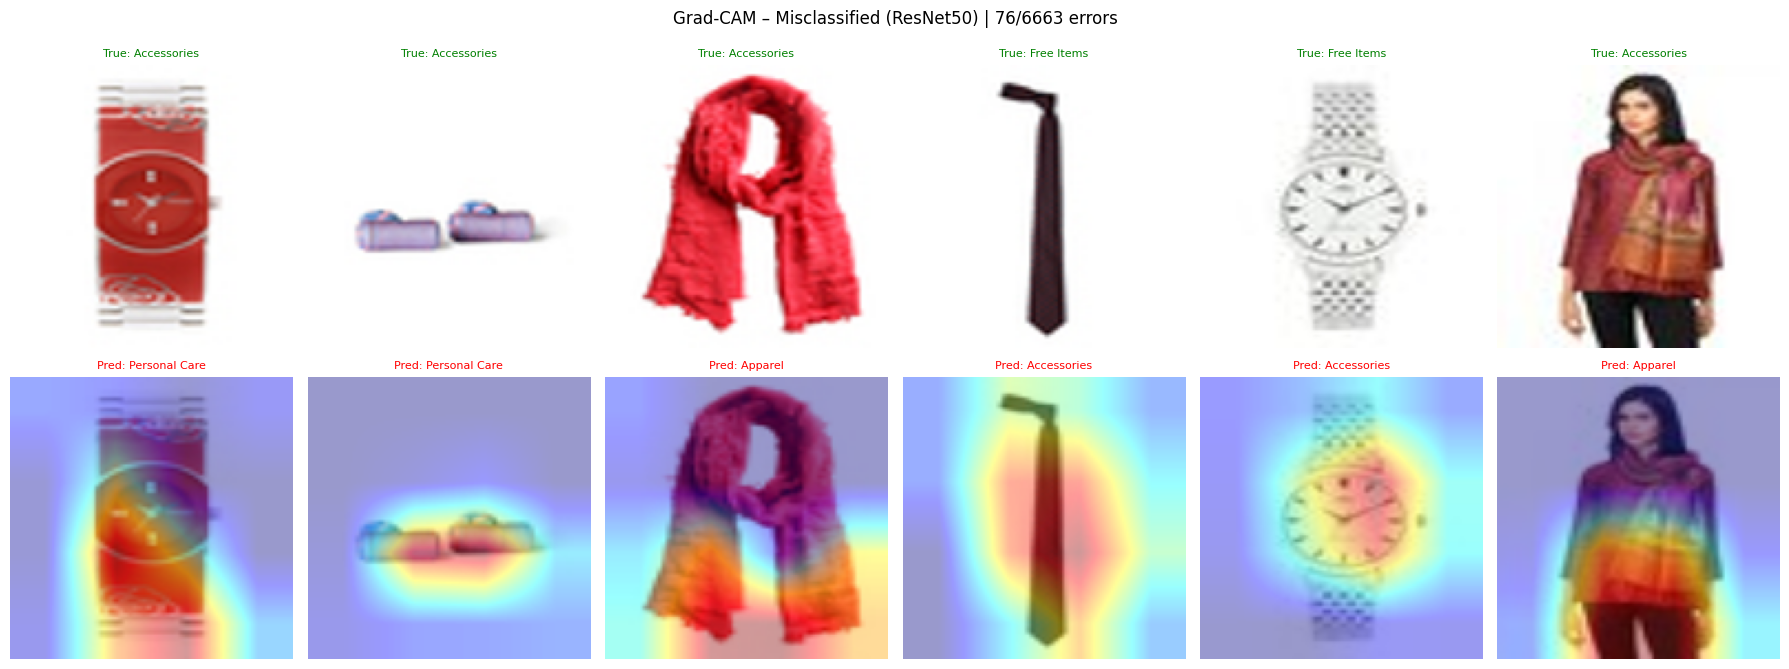

In [26]:
def gradcam_on_misclassified(model, results, test_df_reset, class_names,
                              gradcam_fn, model_name, output_dir,
                              n=6, tl_model=False):
    """
    Show Grad-CAM overlays on misclassified images.
    tl_model=True  → images loaded as 0-255 (backbone preprocess is inside model)
    tl_model=False → images loaded as 0-1   (CNN expects rescaled input)
    """
    y_true, y_pred = results['y_true'], results['y_pred']
    wrong_idx      = np.where(y_true != y_pred)[0][:n]
    if len(wrong_idx) == 0:
        print(f"{model_name}: no misclassified samples."); return

    cols = len(wrong_idx)
    fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
    if cols == 1: axes = axes.reshape(2, 1)

    for col, idx in enumerate(wrong_idx):
        path    = test_df_reset.iloc[idx]['image_path']
        img_pil = Image.open(path).convert('RGB').resize(IMG_SIZE)
        img_np  = np.array(img_pil)

        # Scale for model input
        scale   = 1.0 if tl_model else 255.0
        img_arr = np.expand_dims(img_np / scale, 0).astype('float32')
        heatmap, _ = gradcam_fn(model, img_arr)
        overlay     = overlay_gradcam(path, heatmap)

        axes[0][col].imshow(img_pil)
        axes[0][col].set_title(f"True: {class_names[y_true[idx]]}", fontsize=8, color='green')
        axes[0][col].axis('off')
        axes[1][col].imshow(overlay)
        axes[1][col].set_title(f"Pred: {class_names[y_pred[idx]]}", fontsize=8, color='red')
        axes[1][col].axis('off')

    total_wrong = len(np.where(y_true != y_pred)[0])
    plt.suptitle(f'Grad-CAM – Misclassified ({model_name}) | {total_wrong}/{len(y_true)} errors',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_gradcam_misclassified.pdf', dpi=150, bbox_inches='tight')
    plt.show()


gradcam_on_misclassified(
    cnn_model,
    cnn_results,
    test_df_reset,
    CLASS_NAMES,
    lambda m, x: get_gradcam_heatmap(m, x, last_conv),
    "Custom_CNN",
    OUTPUT_DIR,
    tl_model=False
)
gradcam_on_misclassified(
    mobilenet_model,
    mobilenet_results,
    test_df_reset,
    CLASS_NAMES,
    get_gradcam_heatmap_mobilenet,
    "MobileNetV2",
    OUTPUT_DIR,
    tl_model=True
)
gradcam_on_misclassified(
    resnet_model,
    resnet_results,
    test_df_reset,
    CLASS_NAMES,
    get_gradcam_heatmap_resnet,
    "ResNet50",
    OUTPUT_DIR,
    tl_model=True
)

---
## 🔮 Step 12: SHAP Explanations

SHAP `GradientExplainer` assigns pixel-level attribution values: **red** pixels push the prediction toward the predicted class, **blue** pixels push against it.

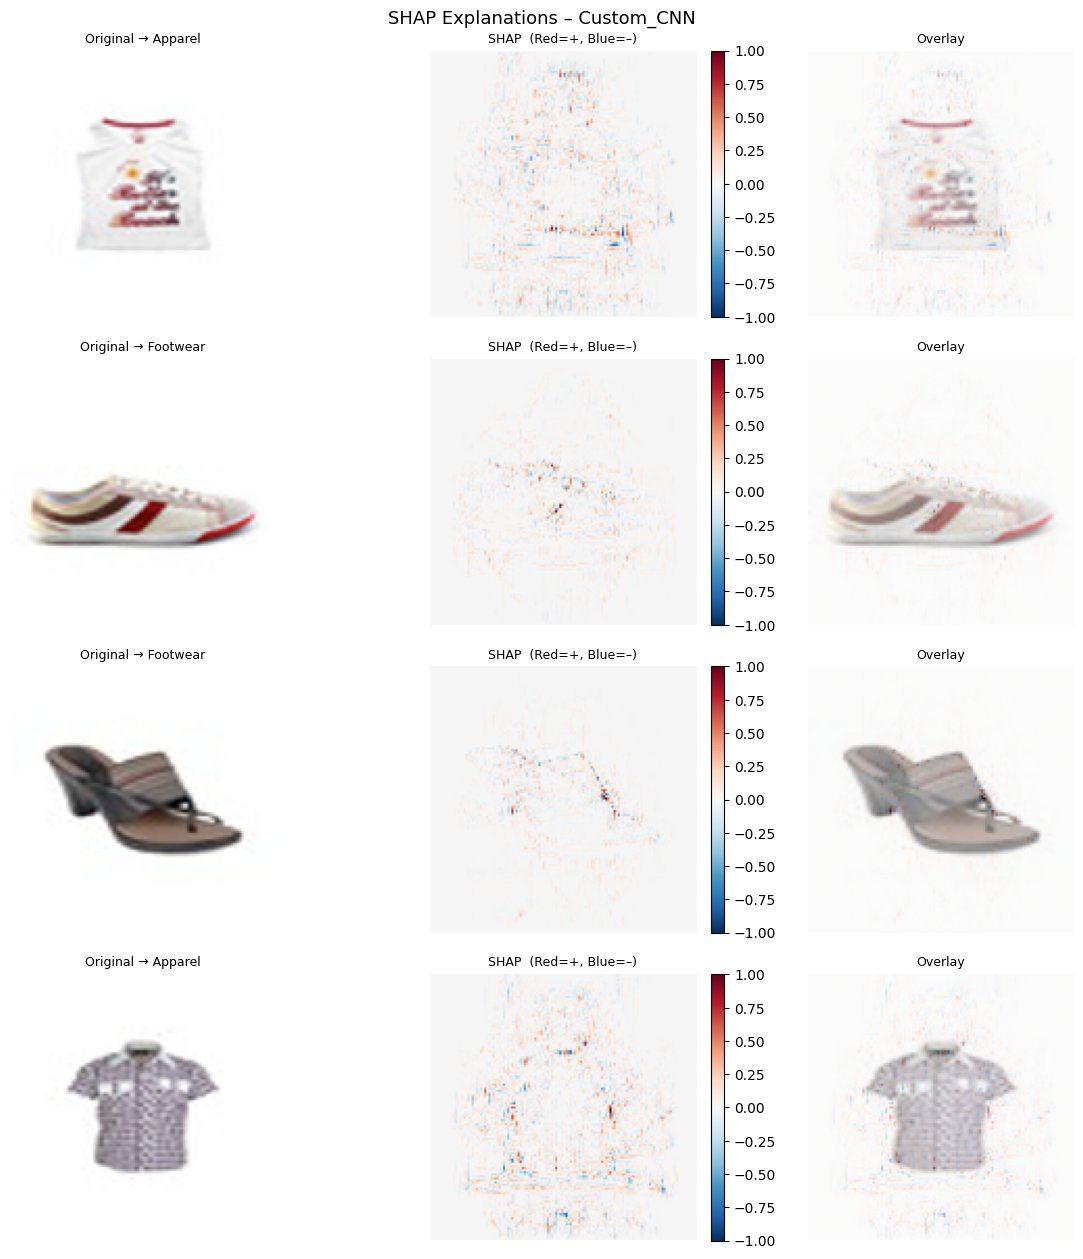

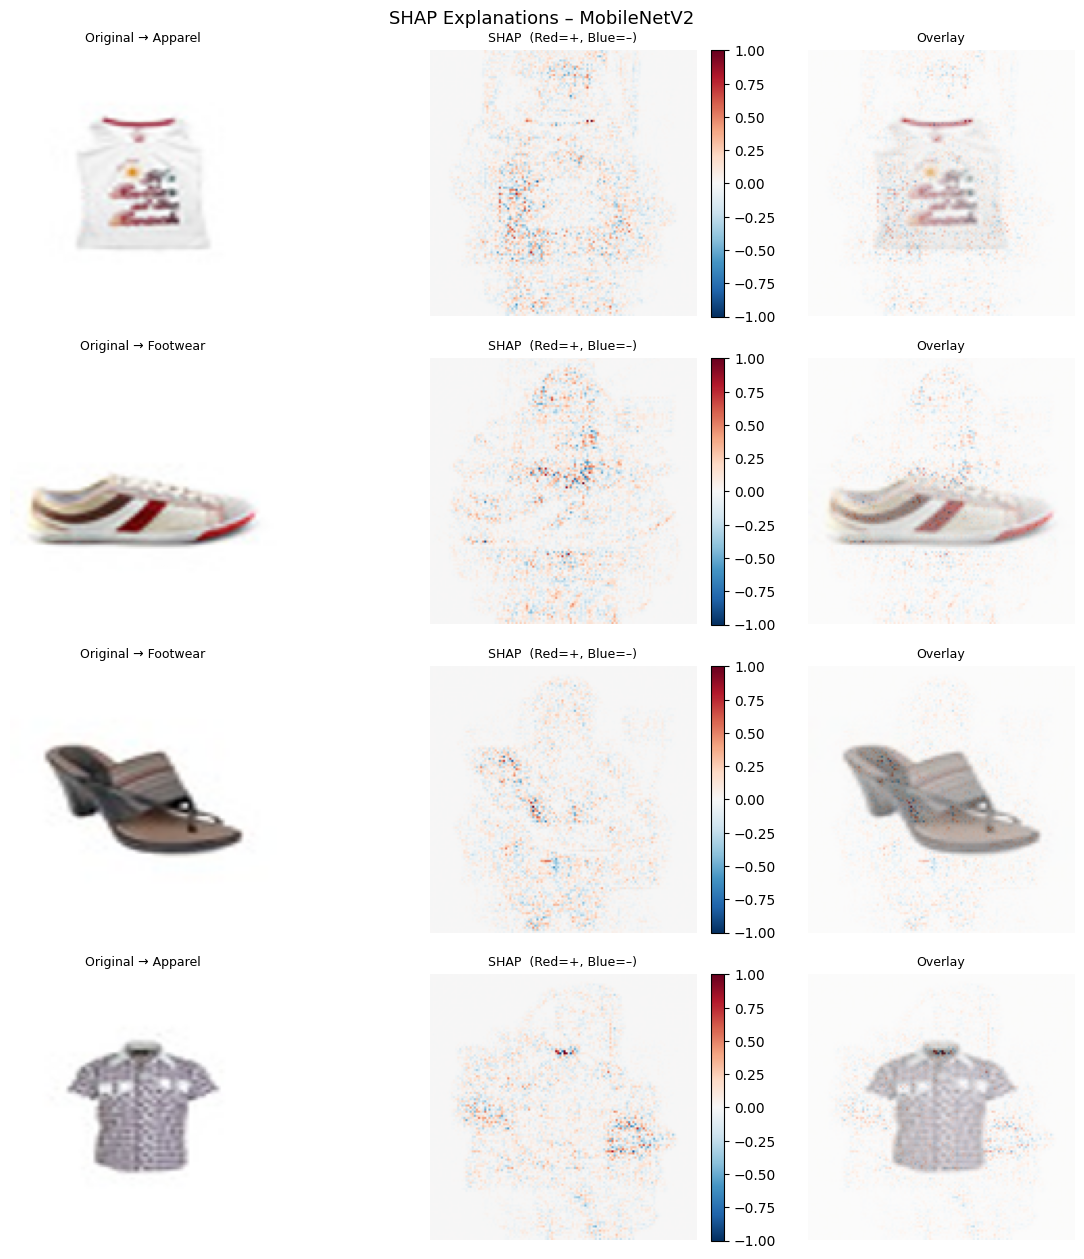

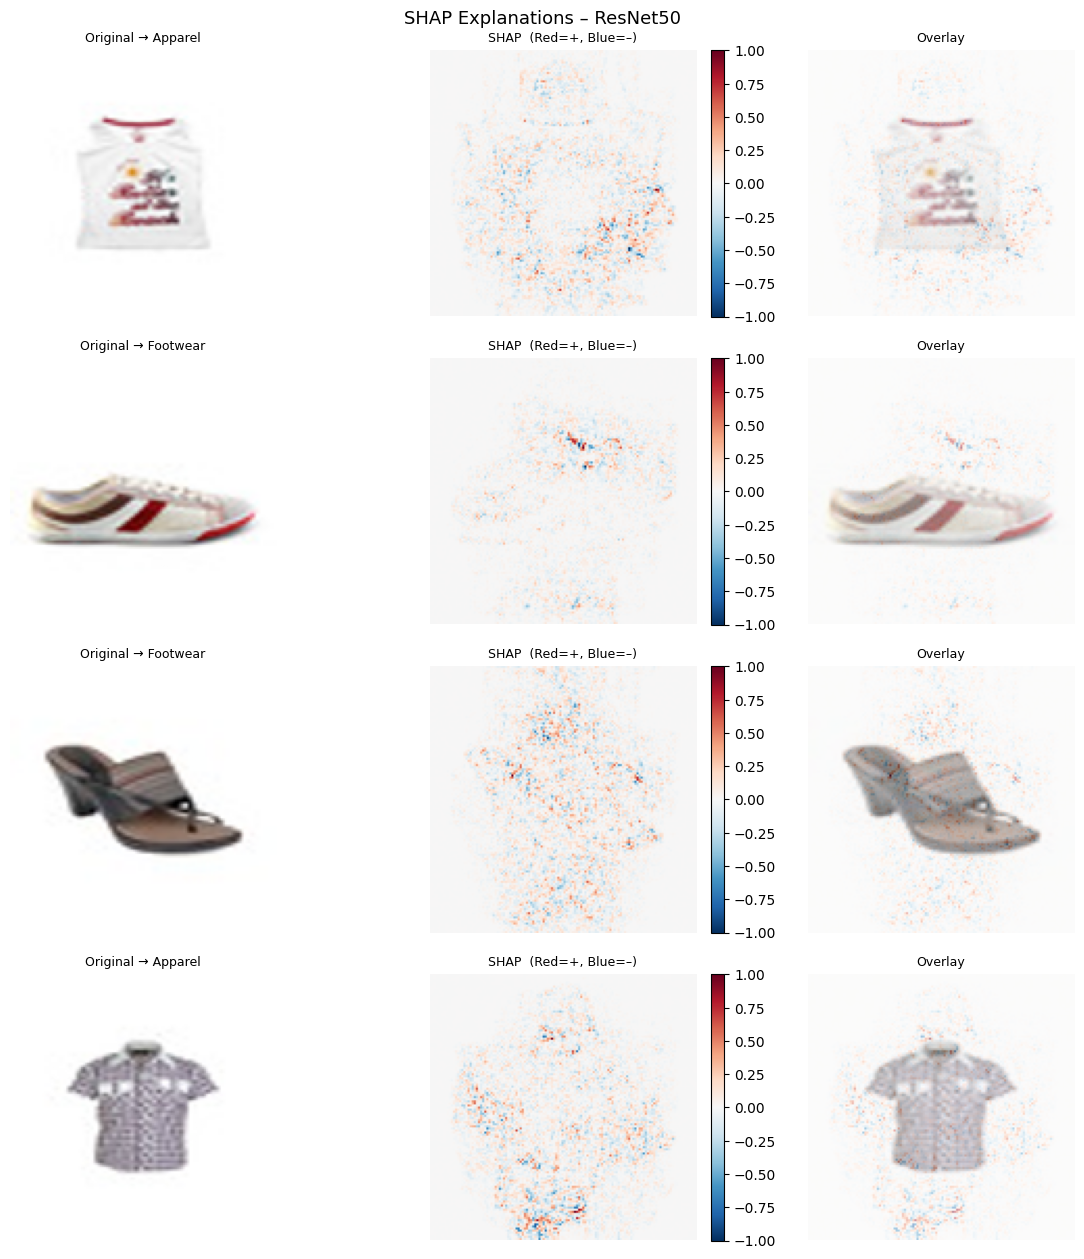

In [27]:
def run_shap(model, test_dataframe, class_names, model_name, output_dir,
             n_background=50, n_explain=4, tl_model=False):
    """
    SHAP GradientExplainer for image classification.
    tl_model=True  → images loaded as 0-255 (backbone preprocess inside model)
    tl_model=False → images loaded as 0-1   (CNN expects rescaled input)
    """
    scale = 1.0 if tl_model else 255.0

    def load_imgs(paths):
        return np.array([
            np.array(Image.open(p).convert('RGB').resize(IMG_SIZE)) / scale
            for p in paths
        ], dtype='float32')

    bg_paths  = test_dataframe.sample(n_background, random_state=SEED)['image_path'].tolist()
    exp_paths = test_dataframe.sample(n_explain, random_state=SEED+1)['image_path'].tolist()
    bg_imgs   = load_imgs(bg_paths)
    exp_imgs  = load_imgs(exp_paths)

    explainer   = shap.GradientExplainer(model, bg_imgs)
    shap_values = explainer.shap_values(exp_imgs)   # list[n_classes] of (n,H,W,C)
    
    preds       = np.argmax(model.predict(exp_imgs, verbose=0), axis=1)

    fig, axes = plt.subplots(n_explain, 3, figsize=(12, n_explain * 3.2))
    for i in range(n_explain):
        # Display image correctly for matplotlib
        disp_img = exp_imgs[i].astype(np.float32)

        if disp_img.max() > 1:
            disp_img = disp_img / 255.0

        disp_img = np.clip(disp_img, 0, 1)

        shap_map = shap_values[i, :, :, :, preds[i]].sum(axis=-1)   # (H, W)
        
        abs_max   = np.abs(shap_map).max() + 1e-8
        shap_norm = shap_map / abs_max                        # [-1, 1]

        axes[i][0].imshow(disp_img); axes[i][0].axis('off')
        axes[i][0].set_title(f"Original → {class_names[preds[i]]}", fontsize=9)

        im = axes[i][1].imshow(shap_norm, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[i][1].set_title("SHAP  (Red=+, Blue=–)", fontsize=9); axes[i][1].axis('off')
        plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)

        blend = (disp_img * 0.55 + plt.cm.RdBu_r((shap_norm+1)/2)[...,:3] * 0.45).clip(0,1)
        axes[i][2].imshow(blend); axes[i][2].set_title("Overlay", fontsize=9); axes[i][2].axis('off')

    plt.suptitle(f'SHAP Explanations – {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_shap.pdf', dpi=150, bbox_inches='tight')
    plt.show()

run_shap(cnn_model,       test_df_reset, CLASS_NAMES, 'Custom_CNN',  OUTPUT_DIR, tl_model=False)
run_shap(mobilenet_model, test_df_reset, CLASS_NAMES, 'MobileNetV2', OUTPUT_DIR, tl_model=True)
run_shap(resnet_model,    test_df_reset, CLASS_NAMES, 'ResNet50',    OUTPUT_DIR, tl_model=True)


---
## 💾 Step 13: Save Models & Final Summary

In [28]:
cnn_model.save(       OUTPUT_DIR / 'custom_cnn_final.keras')
mobilenet_model.save( OUTPUT_DIR / 'mobilenet_final.keras')
resnet_model.save(    OUTPUT_DIR / 'resnet50_final.keras')
print("Models saved.")

# List output files
print(f"\nOutput files in {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:45s}  {f.stat().st_size/1024:7.1f} KB")


Models saved.

Output files in /kaggle/working/outputs:
  Custom_CNN_confusion_matrix.pdf                   16.6 KB
  Custom_CNN_gradcam_misclassified.pdf             244.4 KB
  Custom_CNN_report.csv                              0.3 KB
  Custom_CNN_shap.pdf                              270.6 KB
  MobileNetV2_confusion_matrix.pdf                  16.5 KB
  MobileNetV2_gradcam_misclassified.pdf            312.0 KB
  MobileNetV2_report.csv                             0.3 KB
  MobileNetV2_shap.pdf                             308.0 KB
  ResNet50_confusion_matrix.pdf                     17.0 KB
  ResNet50_gradcam_misclassified.pdf               271.1 KB
  ResNet50_report.csv                                0.3 KB
  ResNet50_shap.pdf                                302.5 KB
  augmented_samples.pdf                            504.4 KB
  best_cnn.keras                                  7762.8 KB
  best_mobilenet.keras                           25206.0 KB
  best_resnet50.keras                       

In [29]:
shutil.make_archive('/kaggle/working/project_outputs', 'zip', OUTPUT_DIR)
print("ZIP created: /kaggle/working/project_outputs.zip")


ZIP created: /kaggle/working/project_outputs.zip


In [30]:
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)
best = comparison.loc[comparison['Accuracy'].astype(float).idxmax(), 'Model']
print(f"\n✅ Best performing model: {best}")



  FINAL RESULTS SUMMARY
      Model  Accuracy  Precision  Recall  Macro F1 Training Time  Parameters
 Custom CNN    0.9766     0.7651  0.7822    0.7732       5538.4s      652069
MobileNetV2    0.9878     0.7876  0.7871    0.7873       2499.6s     2587205
   ResNet50    0.9886     0.7876  0.7886    0.7881       3603.1s    24113541

✅ Best performing model: ResNet50
